In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
 
#Чтение файла « metal_sales.csv»
df = pd.read_csv('PycharmProjects/pythonProject/venv/metal_sales/metal_sales.csv')

df = df.drop(columns=['date', 'product_type'])

label_encoder = LabelEncoder()
df['grade'] = label_encoder.fit_transform(df['grade'])
 
X = df.drop(columns=['grade'])
y = df['grade']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_categorical = to_categorical(y)

#Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_categorical, test_size=0.2, random_state=42)

#Создание нейронной сети
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(y_categorical.shape[1], activation='softmax')
])

#Компиляция
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#Обучение
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

#Оценка
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Точность на тестовой выборке: {test_acc:.4f}")



Epoch 1/50


/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2628/2628 ━━━━━━━━━━━━━━━━━━━━ 2s 547us/step - accuracy: 0.8721 - loss: 0.3365 - val_accuracy: 0.9959 - val_loss: 0.0416
Epoch 2/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 530us/step - accuracy: 0.9972 - loss: 0.0200 - val_accuracy: 0.9982 - val_loss: 0.0091
Epoch 3/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 503us/step - accuracy: 0.9987 - loss: 0.0064 - val_accuracy: 0.9997 - val_loss: 0.0027
Epoch 4/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 509us/step - accuracy: 0.9992 - loss: 0.0035 - val_accuracy: 0.9997 - val_loss: 0.0010
Epoch 5/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 517us/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9999 - val_loss: 9.6283e-04
Epoch 6/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.9992 - val_loss: 0.0046
Epoch 7/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 518us/step - accuracy: 0.9993 - loss: 0.0019 - val_accuracy: 0.9996 - val_loss: 0.0013
Epoch 8/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 520us/step - accuracy: 0.9994 - loss: 

In [2]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras import Input


#Определение нейронных блоков

def dense_block(units, activation='relu'):
    """Создает нейронный блок (Dense + активация)."""
    return Dense(units, activation=activation)

#Группировка блоков в нейронную сеть

def build_classification_network(input_dim, output_dim):
   #Создание модели классификации на основе двух нейронных блоков.
    inputs = Input(shape=(input_dim,))

    #Блок 1
    x = dense_block(64, activation='relu')(inputs)

    #Блок 2
    x = dense_block(64, activation='relu')(x)

    #Выходной слой (softmax для многоклассовой классификации)
    outputs = Dense(output_dim, activation='softmax')(x)

    #Сборка модели
    model = Model(inputs=inputs, outputs=outputs)
    return model


#Пример использования с  12 признаками и 3 классами
model = build_classification_network(input_dim=12, output_dim=3)

#Компиляция
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#Вывод структуры
model.summary()




import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

#Загрузка данных
df = pd.read_csv('PycharmProjects/pythonProject/venv/metal_sales/metal_sales.csv')

#Очистка данных, удаление ненужных столбцов
df = df.drop(columns=['date', 'product_type'])

#Кодирование целевой переменной 'grade'
label_encoder = LabelEncoder()
df['grade'] = label_encoder.fit_transform(df['grade'])

#Разделение на признаки и метку
X = df.drop(columns=['grade'])
y = df['grade']

#Нормализация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Формирование итогового набора данных
normalized_data = pd.DataFrame(X_scaled, columns=X.columns)
normalized_data['grade'] = y

#Просмотр результата
print(normalized_data.head())


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,187 (20.26 KB)

 Trainable params: 5,187 (20.26 KB)

 Non-trainable params: 0 (0.00 B)

   plant_id  product_id  thickness_mm  length_mm  price_per_ton  promotion  \
0 -1.224745   -1.675247     -0.509803   1.725934       0.148879  -0.174617   
1 -1.224745   -1.675247     -0.509803   1.725934       0.141900  -0.174617   
2 -1.224745   -1.675247     -0.509803   1.725934       0.194918  -0.174617   
3 -1.224745   -1.675247     -0.509803   1.725934       0.252446  -0.174617   
4 -1.224745   -1.675247     -0.509803   1.725934       0.223299  -0.174617   

   stock_ton   weekday     month    holiday  sales_ton  prev_day_sales_ton  \
0   0.276947  1.497438 -1.599659  10.984838  -1.193461           -1.765638   
1  -0.579643 -1.497438 -1.599659  10.984838  -1.053888           -1.188991   
2  -2.603857 -0.998292 -1.599659  10.984838  -0.903753           -1.049632   
3  -0.427414 -0.499146 -1.599659  -0.091035  -1.113490           -0.899727   
4  -0.628062  0.000000 -1.599659  -0.091035  -0.949774           -1.109142   

   rolling_7d_mean_ton  rolling_30d_mean_ton  grade  
0       

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

#Загрузка данных
df = pd.read_csv('PycharmProjects/pythonProject/venv/metal_sales/metal_sales.csv')

#Предобработка данных: удаление неинформативных столбцов
df = df.drop(columns=['date', 'product_type'])

#Кодирование категориального признака 'grade' в числовой формат
label_encoder = LabelEncoder()
df['grade'] = label_encoder.fit_transform(df['grade'])

#Разделяе признаков и целевую переменную
X = df.drop(columns=['grade'])
y = df['grade']

#Нормализация числовых признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("Пример данных X_train:")
print(pd.DataFrame(X_train, columns=X.columns).head())


Размер обучающей выборки: (52560, 14)
Размер тестовой выборки: (13140, 14)
Пример данных X_train:
   plant_id  product_id  thickness_mm  length_mm  price_per_ton  promotion  \
0  1.224745   -1.444178      0.697625  -0.663821      -1.778776  -0.174617   
1 -1.224745   -0.173301     -0.912279  -0.663821      -0.124422  -0.174617   
2 -1.224745   -0.057767     -0.509803   1.725934       0.403967  -0.174617   
3 -1.224745    1.097575     -0.509803   1.725934      -1.424119  -0.174617   
4  1.224745   -1.559712      1.905054   0.132764      -0.597283  -0.174617   

   stock_ton   weekday     month   holiday  sales_ton  prev_day_sales_ton  \
0  -0.783280 -0.998292  1.592503 -0.091035   0.839779            0.941323   
1   0.214580  0.499146 -1.019266 -0.091035  -0.177596           -0.375058   
2  -1.138150  0.499146  0.721914 -0.091035  -1.260607           -1.403303   
3  -0.849233 -0.998292 -0.729069 -0.091035  -0.047831           -0.190124   
4   0.681231 -0.499146  0.141521 -0.091035   0.7

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

#Загрузка данных
df = pd.read_csv('PycharmProjects/pythonProject/venv/metal_sales/metal_sales.csv')

#Предобработка
df = df.drop(columns=['date', 'product_type'])

#Кодирование категориального столбца 'grade' в числовой формат
label_encoder = LabelEncoder()
df['grade'] = label_encoder.fit_transform(df['grade'])

#Разделение признаков и меток
X = df.drop(columns=['grade'])
y = df['grade']

#Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

#One-hot кодирование целевой переменной
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

#Создание нейронной сети
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(y_train_cat.shape[1], activation='softmax')
])

#Компиляция модели
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Обучение модели
history = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

#Оценка на тестовых данных
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"\nТочность на тестовой выборке: {test_acc:.4f}")

#Пример предсказания
y_pred = model.predict(X_test[:5])
print("\nПример предсказаний (one-hot):")
print(y_pred)
print("\nПредсказанные классы:", y_pred.argmax(axis=1))
print("Истинные классы:", y_test[:5].values)


Epoch 1/50


/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2628/2628 ━━━━━━━━━━━━━━━━━━━━ 2s 479us/step - accuracy: 0.8756 - loss: 0.3285 - val_accuracy: 0.9941 - val_loss: 0.0402
Epoch 2/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 452us/step - accuracy: 0.9969 - loss: 0.0185 - val_accuracy: 0.9987 - val_loss: 0.0080
Epoch 3/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 454us/step - accuracy: 0.9986 - loss: 0.0067 - val_accuracy: 0.9990 - val_loss: 0.0040
Epoch 4/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 462us/step - accuracy: 0.9989 - loss: 0.0044 - val_accuracy: 0.9987 - val_loss: 0.0050
Epoch 5/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 446us/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 0.9993 - val_loss: 0.0031
Epoch 6/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 447us/step - accuracy: 0.9992 - loss: 0.0023 - val_accuracy: 0.9994 - val_loss: 0.0015
Epoch 7/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 447us/step - accuracy: 0.9994 - loss: 0.0015 - val_accuracy: 0.9997 - val_loss: 0.0021
Epoch 8/50
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 1s 462us/step - accuracy: 0.9993 - loss: 0.00

/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Точность на тестовой выборке: 1.0000
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 238us/step

=== Отчёт по метрикам ===
              precision    recall  f1-score   support

           A       1.00      1.00      1.00      6862
           B       1.00      1.00      1.00      3358
           C       1.00      1.00      1.00      2920

    accuracy                           1.00     13140
   macro avg       1.00      1.00      1.00     13140
weighted avg       1.00      1.00      1.00     13140



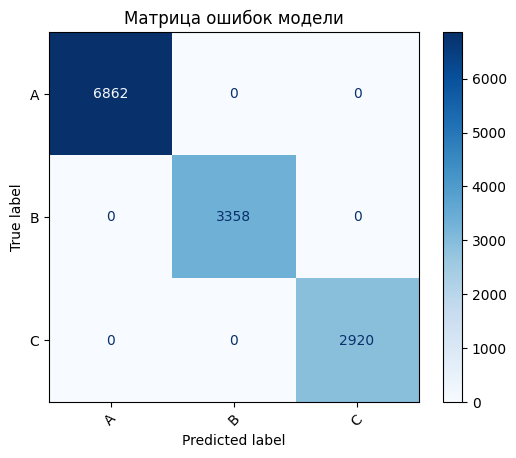


=== Кросс-валидация (5-Fold) ===


/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first la

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

#Загрузка и предобработка данных
df = pd.read_csv('PycharmProjects/pythonProject/venv/metal_sales/metal_sales.csv')
df = df.drop(columns=['date', 'product_type'])

label_encoder = LabelEncoder()
df['grade'] = label_encoder.fit_transform(df['grade'])

X = df.drop(columns=['grade'])
y = df['grade']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)


#Создание модели
def build_model(input_dim, output_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


model = build_model(X_train.shape[1], y_train_cat.shape[1])

#Обучение модели
model.fit(X_train, y_train_cat, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

#Оценка на тесте
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nТочность на тестовой выборке: {test_acc:.4f}")

#Классификационный отчёт
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n=== Отчёт по метрикам ===")
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

#Матрица ошибок
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Матрица ошибок модели")
plt.show()

#Кросс-валидация (K-Fold
print("\n=== Кросс-валидация (5-Fold) ===")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = []

for train_idx, val_idx in kf.split(X_scaled):
    X_tr, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    y_tr_cat = to_categorical(y_tr)
    y_val_cat = to_categorical(y_val)

    model_cv = build_model(X_tr.shape[1], y_tr_cat.shape[1])
    model_cv.fit(X_tr, y_tr_cat, epochs=30, batch_size=16, verbose=0)
    _, acc = model_cv.evaluate(X_val, y_val_cat, verbose=0)
    acc_scores.append(acc)

print(f"Средняя точность по кросс-валидации: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

#Загрузка и подготовка данных
df = pd.read_csv('PycharmProjects/pythonProject/venv/metal_sales/metal_sales.csv')
df = df.drop(columns=['date', 'product_type'])

label_encoder = LabelEncoder()
df['grade'] = label_encoder.fit_transform(df['grade'])

X = df.drop(columns=['grade'])
y = df['grade']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

#Создание модели с оптимизацией
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),  # регуляризация для уменьшения переобучения
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(y_train_cat.shape[1], activation='softmax')
])

#Компиляция модели
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

#Добавление EarlyStopping для минимизации потерь
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

#Обучение
history = model.fit(
    X_train, y_train_cat,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

#Оценка модели
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nМинимальные потери на тесте: {test_loss:.4f}")
print(f"Точность после минимизации потерь: {test_acc:.4f}")

#Визуализация потерь
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Потери на обучении')
plt.plot(history.history['val_loss'], label='Потери на валидации')
plt.title('Динамика функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

#Загрузка и подготовка данных
df = pd.read_csv('PycharmProjects/pythonProject/venv/metal_sales/metal_sales.csv')
df = df.drop(columns=[‘date’, ‘product_type’])

label_encoder = LabelEncoder()
df[‘grade’] = label_encoder.fit_transform(df[‘grade’])

X = df.drop(columns=[‘grade’])
y = df[‘grade’]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

#Модель
model = Sequential([
    Dense(64, activation=’relu’, input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation=’relu’),
    Dropout(0.3),
    Dense(y_train_cat.shape[1], activation=’softmax’)
])

model.compile(optimizer=’adam’, loss=’categorical_crossentropy’, metrics=[‘accuracy’])

# === 3. EarlyStopping для адекватного обучения ===
early_stop = EarlyStopping(monitor=’val_loss’, patience=10, restore_best_weights=True)

#Обучение
history = model.fit(
    X_train, y_train_cat,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

#Оценка 
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f”\n Тестовая точность: {test_acc:.4f}”)
print(f” Тестовые потери (loss): {test_loss:.4f}”)

#Динамика обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history[‘accuracy’], label=’Обучение’)
plt.plot(history.history[‘val_accuracy’], label=’Валидация’)
plt.title(‘Динамика точности’)
plt.xlabel(‘Эпоха’)
plt.ylabel(‘Accuracy’)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history[‘loss’], label=’Обучение’)
plt.plot(history.history[‘val_loss’], label=’Валидация’)
plt.title(‘Динамика функции потерь’)
plt.xlabel(‘Эпоха’)
plt.ylabel(‘Loss’)
plt.legend()
plt.grid(True)
plt.show()

#Анализ ошибок
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(“\n=== Отчёт по классам ===”)
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

#Матрица ошибок
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=’Blues’, xticks_rotation=45)
plt.title(“Матрица ошибок”)
plt.show()

#ROC-кривые
n_classes = y_test_cat.shape[1]
fpr, tpr, roc_auc = {}, {}, {}

for I in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_cat[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for I in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f”{label_encoder.classes_[i]} (AUC={roc_auc[i]:.2f})”)
plt.plot([0, 1], [0, 1], ‘k—', label=’Случайная модель’)
plt.title(“ROC-кривые по классам”)
plt.xlabel(“False Positive Rate”)
plt.ylabel(“True Positive Rate”)
plt.legend()
plt.grid(True)
plt.show()

print(f”Средний AUC: {np.mean(list(roc_auc.values())):.4f}”)
